In [2]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 1.4 MB/s eta 0:01:12
    --------------------------------------- 1.3/101.7 MB 2.2 MB/s eta 0:00:46
   - -------------------------------------- 2.9/101.7 MB 3.6 MB/s eta 0:00:28
   - -------------------------------------- 3.1/101.7 MB 2.8 MB/s eta 0:00:35
   - -------------------------------------- 3.1/101.7 MB 2.8 MB/s eta 0:00:35
   - -------------------------------------- 3.7/101.7 MB 2.6 MB/s eta 0:00:39
   - -------------------------------------- 3.9/101.7 MB 2.3 MB/s eta 0:00:44
   - -------------------------------------- 4.5/101.7 MB 2.3 MB/s eta 0:00:44
   -- ---------------

In [4]:
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/12.1 MB 3.0 MB/s eta 0:00:04
   -------- ------------------------------- 2.6/12.1 MB 5.0 MB/s eta 0:00:02
   -------------- ------------------------- 4.5/12.1 MB 5.4 MB/s eta 0:00:02
   -------------- ------------------------- 4.5/12.1 MB 5.4 MB/s eta 0:00:02
   -------------- ------------------------- 4.5/12.1 MB 5.4 MB/s eta 0:00:02
   -------------- ------------------------- 4.5/12.1 MB 5.4 MB/s eta 0:00:02
   --------------- ------------------------ 4.7/12.1 MB 2.7 MB/s eta 0:00:03
   --------------- ------------------------ 4.7/12.1 MB 2.7 MB/s eta 0:00:03
   --------------- ------------------------ 4.7/12.1 MB 2.7 MB/s eta 0:00:03
   --------------- ------------------------ 4.7/12.1 MB 2.7 MB/s eta 0:00:03
   ---------------- ----------------------- 5.0/12.1 MB 1.9 MB/s eta 0:00:04
   ----------

                     Global_active_power
Datetime                                
2006-12-16 17:24:00                4.216
2006-12-16 17:25:00                5.360
2006-12-16 17:26:00                5.374
2006-12-16 17:27:00                5.388
2006-12-16 17:28:00                3.666


C:\Users\faraz\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\faraz\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\faraz\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\faraz\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\U


Model Performance:
ARIMA -> MAE: 0.5530, RMSE: 0.7891
Prophet -> MAE: 0.5738, RMSE: 0.7450
XGBoost -> MAE: 0.4988, RMSE: 0.6672


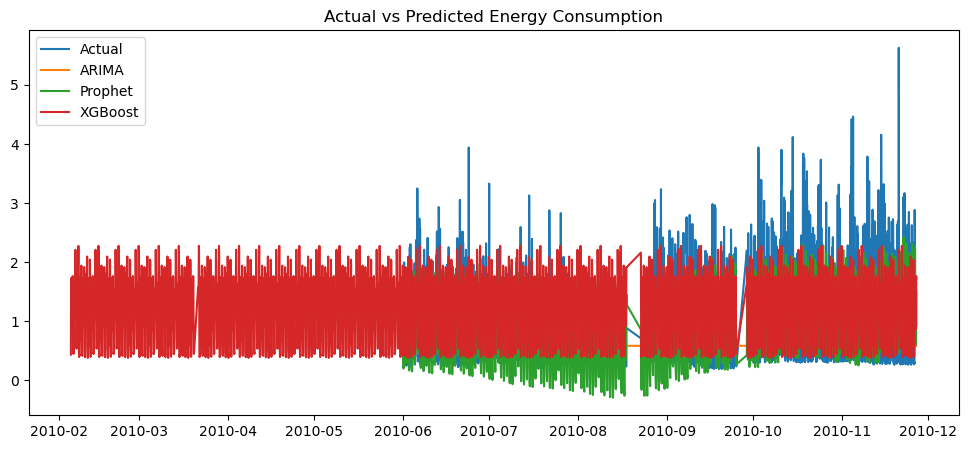

In [7]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

from statsmodels.tsa.arima.model import ARIMA
from xgboost import XGBRegressor
from prophet import Prophet


# ==============================
# 2. Load Dataset
# ==============================
data = pd.read_csv("household_power_consumption.txt", sep=';', low_memory=False)

# Fix date parsing
data['Datetime'] = pd.to_datetime(
    data['Date'] + ' ' + data['Time'],
    dayfirst=True,
    errors='coerce'
)

# Keep only required column
data = data[['Datetime', 'Global_active_power']]

# Convert to numeric
data['Global_active_power'] = pd.to_numeric(data['Global_active_power'], errors='coerce')

# Remove NaN / invalid values
data = data.replace([np.inf, -np.inf], np.nan)
data.dropna(inplace=True)

# Set index
data.set_index('Datetime', inplace=True)

print(data.head())


# ==============================
# 3. Resample (Hourly)
# ==============================
data = data.resample('h').mean()


# ==============================
# 4. Feature Engineering
# ==============================
data['hour'] = data.index.hour
data['day'] = data.index.dayofweek

# Clean again after resampling
data = data.replace([np.inf, -np.inf], np.nan)
data.dropna(inplace=True)


# ==============================
# 5. Train-Test Split
# ==============================
train = data[:'2010-06-01']
test = data['2010-06-01':]


# ==============================
# 6. ARIMA Model
# ==============================
arima_model = ARIMA(train['Global_active_power'], order=(5,1,0))
arima_result = arima_model.fit()

arima_pred = arima_result.forecast(steps=len(test))


# ==============================
# 7. Prophet Model
# ==============================
prophet_data = data.reset_index()
prophet_data = prophet_data.rename(columns={'Datetime':'ds', 'Global_active_power':'y'})

train_p = prophet_data[prophet_data['ds'] < '2010-06-01']
test_p = prophet_data[prophet_data['ds'] >= '2010-06-01']

model = Prophet()
model.fit(train_p)

future = model.make_future_dataframe(periods=len(test_p), freq='h')
forecast = model.predict(future)

prophet_pred = forecast['yhat'][-len(test_p):].values


# ==============================
# 8. XGBoost Model
# ==============================
features = ['hour', 'day']

X = data[features].astype(float)
y = data['Global_active_power'].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle=False, test_size=0.2
)

xgb = XGBRegressor()
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)


# ==============================
# 9. Evaluation
# ==============================
def evaluate(true, pred, name):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    print(f"{name} -> MAE: {mae:.4f}, RMSE: {rmse:.4f}")

print("\nModel Performance:")
evaluate(test['Global_active_power'], arima_pred, "ARIMA")
evaluate(test_p['y'], prophet_pred, "Prophet")
evaluate(y_test, xgb_pred, "XGBoost")


# ==============================
# 10. Plot Results
# ==============================
plt.figure(figsize=(12,5))

plt.plot(test.index, test['Global_active_power'], label='Actual')
plt.plot(test.index, arima_pred, label='ARIMA')
plt.plot(test.index, prophet_pred, label='Prophet')
plt.plot(y_test.index, xgb_pred, label='XGBoost')

plt.legend()
plt.title("Actual vs Predicted Energy Consumption")
plt.show()